Dataset Setup & Preprocessing

In [5]:
import os
import zipfile

# Define dataset path
dataset_path = "C:/Users/Vandan/Downloads/statefarm_dataset.zip"
extract_path = "statefarm_data"

# Extract the dataset
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")


Dataset extracted successfully!


Load & Organize the Data

In [1]:
import pandas as pd
import os
import shutil

# Define the dataset directories
base_dir = "statefarm_data/imgs"
train_dir = os.path.join(base_dir, "train")

# Create directories for categories
categories = ["c0_safe", "c1_texting_right", "c2_phone_right", "c3_eating",
              "c4_looking_back", "c5_makeup", "c6_talking_passenger",
              "c7_texting_left", "c8_phone_left", "c9_adjust_radio"]

for category in categories:
    os.makedirs(os.path.join(train_dir, category), exist_ok=True)

# Move images to respective category folders
for category in categories:
    category_label = category.split("_")[0]  # Extract category number
    src_folder = os.path.join(train_dir, category_label)
    dst_folder = os.path.join(train_dir, category)
    
    for file in os.listdir(src_folder):
        shutil.move(os.path.join(src_folder, file), os.path.join(dst_folder, file))

print("Dataset organized into class folders.")


Dataset organized into class folders.


 Data Augmentation & Preprocessing

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image size & batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,        # Normalize pixel values
    rotation_range=20,      # Random rotation
    width_shift_range=0.2,  # Horizontal shift
    height_shift_range=0.2, # Vertical shift
    shear_range=0.2,        # Shear transformation
    zoom_range=0.2,         # Zoom in/out
    horizontal_flip=True,   # Flip images
    validation_split=0.2    # Splitting data for validation
)

# Load dataset for training & validation
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

print("Dataset preprocessed & ready for training!")


Found 17943 images belonging to 20 classes.
Found 4481 images belonging to 20 classes.
Dataset preprocessed & ready for training!


Preprocessing Video-Based Dataset (Drive&Act, AI City)

import cv2

video_path = "sample_video.mp4"  # Change this to the actual video path
output_folder = "extracted_frames"

os.makedirs(output_folder, exist_ok=True)

# Open the video
cap = cv2.VideoCapture(video_path)
frame_rate = cap.get(5)  # Get frame rate
frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Save every 5th frame
    if frame_count % 5 == 0:
        frame_path = os.path.join(output_folder, f"frame_{frame_count}.jpg")
        cv2.imwrite(frame_path, frame)

    frame_count += 1

cap.release()
cv2.destroyAllWindows()
print(f"Extracted {frame_count} frames from video.")


Model Training for Image-Based Dataset

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

Define Hyperparameters & Load Dataset

In [4]:
# Define image size & batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load preprocessed dataset
train_dir = "statefarm_data/imgs/train"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80% Train, 20% Validation Split
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

num_classes = len(train_generator.class_indices)
print(f"Number of Classes: {num_classes}")


Found 17943 images belonging to 20 classes.
Found 4481 images belonging to 20 classes.
Number of Classes: 20


Define CNN Model

In [6]:
# Build CNN Model
num_classes = 20
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),  # Prevent Overfitting
    Dense(num_classes, activation='softmax')  # Output layer
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │      44,302,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 20)                  │          10,260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,406,356 (169.40 MB)

 Trainable params: 44,406,356 (169.40 MB)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [7]:
print(len(train_generator))

561


In [8]:
import os
print(os.listdir("statefarm_data"))

['driver_imgs_list.csv', 'imgs', 'sample_submission.csv', 'train']


In [9]:
# Train the model
EPOCHS = 20  # Increase for better accuracy

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    verbose=1
)


Epoch 1/20


C:\Users\Vandan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


561/561 ━━━━━━━━━━━━━━━━━━━━ 306s 543ms/step - accuracy: 0.5516 - loss: 1.4836 - val_accuracy: 0.9857 - val_loss: 0.0731
Epoch 2/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 309s 550ms/step - accuracy: 0.9698 - loss: 0.0974 - val_accuracy: 0.9877 - val_loss: 0.0368
Epoch 3/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 296s 527ms/step - accuracy: 0.9818 - loss: 0.0562 - val_accuracy: 0.9929 - val_loss: 0.0257
Epoch 4/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 292s 521ms/step - accuracy: 0.9908 - loss: 0.0288 - val_accuracy: 0.9946 - val_loss: 0.0211
Epoch 5/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 289s 515ms/step - accuracy: 0.9914 - loss: 0.0281 - val_accuracy: 0.9920 - val_loss: 0.0271
Epoch 6/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 277s 495ms/step - accuracy: 0.9907 - loss: 0.0288 - val_accuracy: 0.9955 - val_loss: 0.0188
Epoch 7/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 276s 493ms/step - accuracy: 0.9937 - loss: 0.0191 - val_accuracy: 0.9940 - val_loss: 0.0239
Epoch 8/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 276s 491ms/step - accuracy: 0.9929 - loss: 0.02

Plot Accuracy & Loss

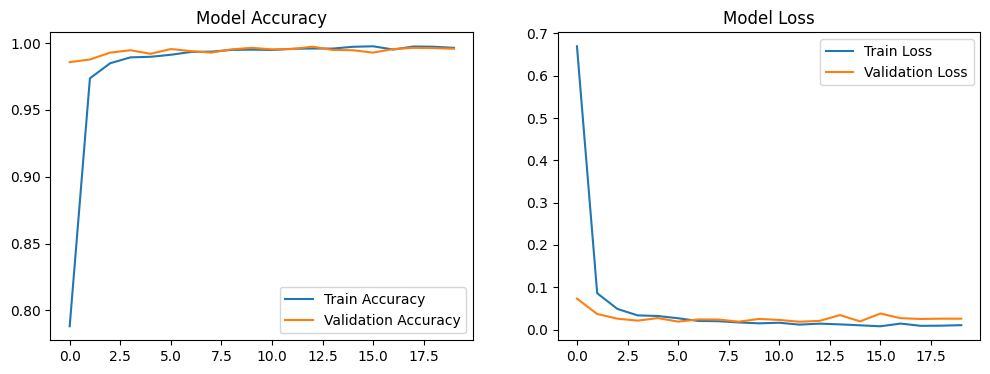

In [10]:
# Plot Training Accuracy & Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")

plt.show()


Save the Model for Deployment

In [21]:
model.save("driver_action_model.h5")
print("Model saved successfully!")


Model saved successfully!


### Deployement with Opencv

In [22]:
import tensorflow as tf

# Load the trained model
model = tf.keras.models.load_model("driver_action_model.h5")

# Recompile the model to ensure metrics are available
model.compile(
    optimizer=tf.keras.optimizers.Adam(), 
    loss="categorical_crossentropy", 
    metrics=["accuracy"]
)

print("Model successfully loaded and compiled!")

Model successfully loaded and compiled!


In [25]:
import cv2
import numpy as np
import tensorflow as tf
import winsound  # For Windows alert sounds (use `playsound` for other OS)

# Load the trained model
model = tf.keras.models.load_model("driver_action_model.h5")

# Define class labels
class_labels = ["Safe Driving", "Texting Right", "Phone Right", "Eating", 
                "Looking Back", "Makeup", "Talking Passenger", "Texting Left",
                "Phone Left", "Adjusting Radio"]

# Initialize webcam
cap = cv2.VideoCapture(1)  # Use 0 for the default webcam, change if using external cam

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Preprocess frame for model
    img = cv2.resize(frame, (224, 224)) / 255.0  # Resize & normalize
    img = np.expand_dims(img, axis=0)  # Add batch dimension

    # Make prediction
    prediction = model.predict(img)
    predicted_class = np.argmax(prediction)
    action = class_labels[predicted_class]  # Define action variable

    # Display action on screen
    cv2.putText(frame, f"Action: {action}", (50, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Add alert for dangerous behavior
    if action in ["Texting Right", "Texting Left", "Phone Right", "Phone Left"]:
        winsound.Beep(1000, 500)  # Alert sound for Windows
        # Alternative: `playsound('alert.mp3')` for other OS

    # Show the frame
    cv2.imshow("Driver Action Detection", frame)

    # Exit on 'q' key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()